### 工作進度  
* 「波段量化交易」系統雛形開發，規格簡述於下：  
   1. 實作「底部型態反轉交易」(參照「第一堂課-底型反轉_240809_筆記.pptx」內容)。  
      將手繪型態量化，參考以下案例：  
      - 手繪圖表：  
        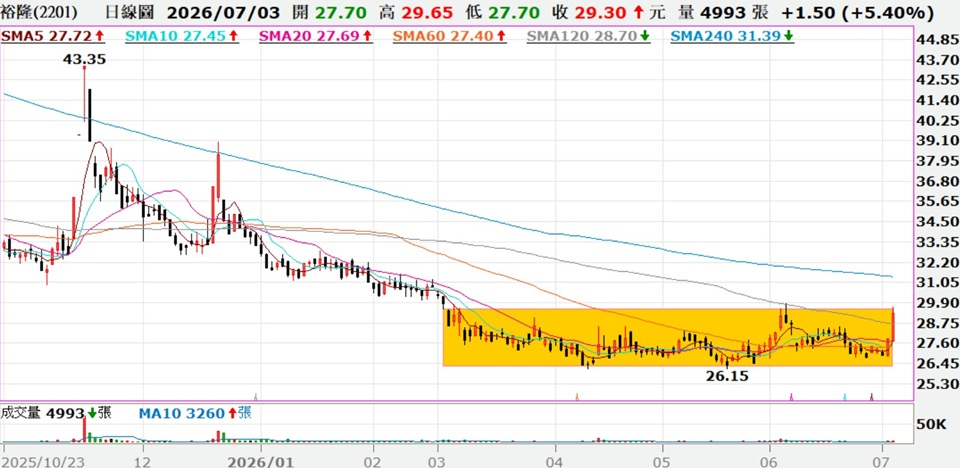  
      - 底部型態描述：  
        ```  
        {
            "stock_id" : "2201",
            "pattern_range" : ["2025-12-10"],
            "neckline_turning_points":[
               {"date":"2026-06-04","price_type":"Open"}
            ],
            "bottom_point" : {"date":"2026-04-10","price_type":"Close"} 
        }
        ```  
    2. TODO
      

In [ ]:
import os
import pandas as pd
import numpy as np
import datetime
import json

import shioaji as sj

from dotenv import load_dotenv, find_dotenv
from FinMind.data import DataLoader

import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf

import time

In [ ]:
###### 【內部函式】 回傳今天指定時間的 datetime 物件 ######
def get_today_fixed_time(hour: int, minute: int, second: int = 0):
    """
    回傳今天指定時間的 datetime 物件。
    
    :param hour: 小時 (0-23)
    :param minute: 分鐘 (0-59)
    :param second: 秒 (0-59)
    :return: datetime 物件
    """
    # 基本輸入驗證
    if not (0 <= hour <= 23 and 0 <= minute <= 59 and 0 <= second <= 59):
        raise ValueError("時間參數超出範圍")

    today = datetime.datetime.today()
    fixed_time = datetime.datetime.combine(today.date(), datetime.time(hour, minute, second))
    return fixed_time
    
###### 【內部函式】 確認列表是否依序排列 ######
def is_sorted(lst):
    return all(lst[i] <= lst[i+1] for i in range(len(lst) - 1))
    
###### 【內部函式】 當日Ｋ價格資料為零時之修正函式 ######
def correcting_zero_price_issue( daily_price_df, debug = False) :
    # 開啟寫時複製(Copy-on-Write)
    copy_on_write = pd.options.mode.copy_on_write
    pd.options.mode.copy_on_write = True
    
    # 找出開盤價、最高價、收盤價與最低價皆為0的價格資料
    zero_prices_df =  daily_price_df[(daily_price_df['Open'] == 0.0) & (daily_price_df['High'] == 0.0) & (daily_price_df['Low'] == 0.0) & (daily_price_df['Close'] == 0.0)]
    if zero_prices_df.empty is False :
        zero_prices_idx = zero_prices_df.index
        df_first_idx    = daily_price_df.iloc[0].name
        for idx in zero_prices_idx :
            if (idx - 1) >= df_first_idx :
                # 當開盤價、最高價、收盤價與最低價皆為0時，會用前一個交易日的收盤價來做修正
                prev_close_price = daily_price_df.loc[idx-1]['Close']
                prev_stock_id    = daily_price_df.loc[idx-1]['StockID']
                curr_stock_id    = daily_price_df.loc[idx]['StockID']
                if debug is True :
                    print('ＤＥＢＵＧ ： 〈代碼：{}，日期：{}〉  修改前：開 ＝ {} 高 ＝ {} 低 ＝ {} 收 ＝ {}'.format(curr_stock_id,daily_price_df.loc[idx]['Date'],daily_price_df.loc[idx,'Open'],daily_price_df.loc[idx,'High'],daily_price_df.loc[idx,'Low'],daily_price_df.loc[idx,'Close']), end='')
                daily_price_df.loc[idx,'Open']  = prev_close_price
                daily_price_df.loc[idx,'High']  = prev_close_price
                daily_price_df.loc[idx,'Low']   = prev_close_price
                daily_price_df.loc[idx,'Close'] = prev_close_price
                if debug is True :
                    print(' ， 修改後：開 ＝ {} 高 ＝ {} 低 ＝ {} 收 ＝ {}'.format(daily_price_df.loc[idx,'Open'],daily_price_df.loc[idx,'High'],daily_price_df.loc[idx,'Low'],daily_price_df.loc[idx,'Close']))
            else :
                pass
    
    # 還原初始狀態
    pd.options.mode.copy_on_write = copy_on_write
    
##### 【內部函式】 日期轉索引 #####
def date_to_index(df_in,date_in) :
    number_array = df_in.index == date_in
    idx = 0
    for number_index in number_array :
        if number_index == True :
            break
        idx = idx + 1
    return idx

In [ ]:
##### 波段量化交易 #####
class SwingQuantTrading() :
    
    ### SwingQuantTrading類別之建構子 ###
    def __init__( self, debug = False) :
        
        # 設定除錯旗標
        self._debug = debug
        
        # 設定FinMind API
        print(find_dotenv())
        load_dotenv(find_dotenv())
        token = os.environ.get('FINMIND_TOKEN')
        api = DataLoader()
        api.login_by_token(api_token=token)
        self._finmind_api = api
        
    ### 列印除錯訊息之內部方法 ###
    def _debug_print( self, msg) :
        if self._debug is True :
            print("ＤＥＢＵＧ ： {}".format(msg))
    
    ### 獲取歷史價量資料之內部方法 ###
    def _daily_price_history( self, stock_id, start_date) :
        today     = datetime.datetime.today()
        yesterday = (today - datetime.timedelta(days=1))
        end_date  = yesterday.strftime("%Y-%m-%d")
        self._debug_print('歷史價量資料　開始日期 ＝ {} ， 結束日期 ＝ {}'.format(start_date,end_date))
        
        df = self._finmind_api.taiwan_stock_daily(stock_id=stock_id,start_date=start_date,end_date=end_date)
        
        # 將FinMind API技術面資料轉換為資料庫所需格式
        df_daily_price = df.drop(columns=['spread','Trading_turnover'])
        df_daily_price = df_daily_price.rename(columns={'date':'Date','stock_id':'StockID','Trading_Volume':'Volume','Trading_money':'Value','open':'Open','max':'High','min':'Low','close':'Close'})
        # 保存格式：日期、股票代碼、開盤價、最高價、最低價、收盤價、成交量與成交值
        df_daily_price = df_daily_price[['Date', 'StockID', 'Open', 'High', 'Low', 'Close', 'Volume', 'Value']]
        correcting_zero_price_issue(df_daily_price)
        
        daily_price_df           = df_daily_price.copy()
        daily_price_df           = daily_price_df.drop(columns=['Value','StockID'])
        daily_price_df['Volume'] = daily_price_df['Volume'].div(1000)
        daily_price_df['Volume'] = daily_price_df['Volume'].round()
        daily_price_df['Volume'] = daily_price_df['Volume'].astype('int64')

        return daily_price_df
        
    ### 獲取即時價量資料之內部方法 ###
    def _stock_real_time_price( self, stock_id) :
        
        df = self._finmind_api.taiwan_stock_tick_snapshot(stock_id=stock_id)

        # 價格漲跌
        change_price = df.iloc[0]['change_price']
        # 漲跌幅
        change_rate = df.iloc[0]['change_rate']
        
        today_daily_price_df = df[['date','open', 'high','low','close','total_volume']]
        today_daily_price_df = today_daily_price_df.rename(columns={'date':'Date','open':'Open','high':'High','low':'Low','close':'Close','total_volume':'Volume'})
        # 日期
        today_daily_price_date = pd.to_datetime(today_daily_price_df['Date']).dt.strftime('%Y-%m-%d')
        today_daily_price_date = today_daily_price_date.iat[0]
        # 時間
        today_daily_price_time = pd.to_datetime(today_daily_price_df['Date']).dt.strftime('%H:%M:%S')
        today_daily_price_time = today_daily_price_time.iat[0]
        today_daily_price_df['Date'] = today_daily_price_date
        
        return today_daily_price_df,today_daily_price_date,today_daily_price_time,change_price,change_rate
        
    ### 獲取預估量之內部方法 ###
    def _stock_volume_estimate( self, daily_price_df) :
        
        # 目前時間
        current_time = datetime.datetime.now()
        # 開盤時間
        open_time = get_today_fixed_time(9,0,0)
        # 收盤時間
        close_time = get_today_fixed_time(13,30,0)

        # 到收盤還有幾分鐘
        delta_time = close_time - current_time
        minutes_to_close = delta_time.total_seconds() // 60
        minutes_to_close = int(minutes_to_close)
        self._debug_print('到收盤還剩{}分鐘'.format(minutes_to_close))

        # 今天以前的日均量
        open_minutes = 270
        range_volume = daily_price_df[-21:-1]['Volume'].to_numpy()
        avg_day_vol = int(np.average(range_volume))
        avg_min_vol_in_day = avg_day_vol // open_minutes
        avg_min_vol_in_day = int(avg_min_vol_in_day)
        self._debug_print('日均量 ＝ {} ， 平均分鐘量 ＝ {}  '.format(avg_day_vol,avg_min_vol_in_day))

        # 預估量
        volume = daily_price_df.iloc[-1]['Volume']
        left_vo = minutes_to_close * avg_min_vol_in_day
        est_vot = volume + left_vo
        self._debug_print('目前量 ＝ {} ， 剩餘時間估計量 ＝ {} ， 最終估計量 ＝ {}'.format(volume,left_vo,est_vot))

        # 調整：如果預估量估的太大該怎麼辦？
        # TODO：盤中持續進行確認
        delta_time = current_time - open_time
        elapse_minutes = int(delta_time.total_seconds() // 60)
        elapse_est_volume = elapse_minutes * avg_min_vol_in_day
        self._debug_print('目前量 ＝ {} ，開盤至今時間（{}分）之估計量 ＝ {}'.format(volume,elapse_minutes,elapse_est_volume))
        if (volume/elapse_est_volume) < 1.0 :
            adj_left_vo = int(left_vo * (volume/elapse_est_volume))
            adj_est_vot = volume + adj_left_vo
            self._debug_print('【調整後】剩餘時間估計量 ＝ {} ，【調整後】 最終估計量 ＝ {}'.format(adj_left_vo,adj_est_vot))
            return adj_est_vot

        return est_vot
    
    ### 底部型態描述處理之內部方法 ###
    def _bottom_pattern_description_processing( self, desc_file='bottom_patterns.json', plot=False) :
        results = []
        with open(desc_file, 'r') as file:
            json_data = json.load(file)
        for bottom_pattern in json_data :
            self._debug_print('底部型態描述 ＝ {}'.format(bottom_pattern))
            # 取得股票代碼
            stock_id = bottom_pattern['stock_id']
            # 取得底部範圍
            pattern_range = bottom_pattern['pattern_range']
            price_range_start = pattern_range[0]
            # 載入歷史價格資料
            historical_prices_df = self._daily_price_history(stock_id,price_range_start)
            historical_prices_df['Date']   = historical_prices_df['Date'].astype('datetime64[ns]')
            historical_prices_df.set_index(historical_prices_df['Date'],inplace=True)
            historical_prices_df.drop(columns=['Date'],inplace=True)
            if len(pattern_range) == 1 :
                # 如果沒有指定範圍結束日期，預設為歷史資料的最後一筆日期(代表最後一個交易日)
                price_range_end = historical_prices_df.iloc[-1].name.strftime("%Y-%m-%d")
            elif len(pattern_range) == 2 :
                price_range_end = pattern_range[1]
                historical_prices_df = historical_prices_df[:price_range_end]
                display(historical_prices_df)
            else :
                raise ValueError("底部範圍格式有誤")
            print(price_range_start,price_range_end)
            # 頸線斜截式計算
            neckline_turning_points = bottom_pattern['neckline_turning_points']
            first_turning_point_idx = date_to_index(historical_prices_df,neckline_turning_points[0]['date'])
            if len(neckline_turning_points) > 1 :
                neckline_x = []
                neckline_y = []
                for turning_point in neckline_turning_points :
                    turning_point_idx = date_to_index(historical_prices_df,turning_point['date'])
                    neckline_x.append(turning_point_idx - first_turning_point_idx)
                    neckline_y.append(historical_prices_df.iloc[turning_point_idx][turning_point['price_type']])
                if is_sorted(neckline_x) is True :
                    neckline_slope,neckline_intercept = np.polyfit(neckline_x,neckline_y,1)
                else :
                    raise ValueError("頸線轉折點列表有誤")
                self._debug_print('頸線轉折點 → Ｘ ＝ {} ， Ｙ = {}'.format(neckline_x,neckline_y))
            elif len(neckline_turning_points) == 1 :
                neckline_slope = 0
                neckline_intercept = historical_prices_df.loc[neckline_turning_points[0]['date']][neckline_turning_points[0]['price_type']]
            else :
                raise ValueError("頸線轉折點列表有誤")
            self._debug_print('頸線斜率 ＝ {} ， 頸線截距 ＝ {}'.format(neckline_slope,neckline_intercept))
            # 找出頸線開始位置，並設定對應價格
            range_start_idx         = date_to_index(historical_prices_df,historical_prices_df.iloc[0].name.strftime("%Y-%m-%d"))
            neckline_start_idx      = range_start_idx
            for idx in range(first_turning_point_idx,range_start_idx,-1) :
                neckline_idx_price = (neckline_slope * (idx - first_turning_point_idx)) + neckline_intercept
                if historical_prices_df.iloc[idx]['Close'] > (neckline_idx_price * 1.03) or historical_prices_df.iloc[idx]['Open'] > (neckline_idx_price * 1.03) : 
                    neckline_start_idx = idx
                    break
            neckline_start_date  = historical_prices_df.iloc[neckline_start_idx].name.strftime("%Y-%m-%d")
            neckline_start_price = (neckline_slope * (neckline_start_idx - first_turning_point_idx)) + neckline_intercept
            # 設定頸線結束位置，並設定對應價格
            neckline_end_idx   = date_to_index(historical_prices_df,historical_prices_df.iloc[-1].name.strftime("%Y-%m-%d"))
            neckline_end_date  = historical_prices_df.iloc[neckline_end_idx].name.strftime("%Y-%m-%d")
            neckline_end_price = (neckline_slope * (neckline_end_idx - first_turning_point_idx)) + neckline_intercept
            self._debug_print('頸線開始日期 ＝ {} ， 頸線開始價格 ＝ {} ， 頸線結束日期 ＝ {} ， 頸線結束價格 ＝ {}'.format(neckline_start_date,neckline_start_price,neckline_end_date,neckline_end_price))
            # 檢查是否突破
            last_turning_point_idx = date_to_index(historical_prices_df,neckline_turning_points[-1]['date'])
            bottom_pattern_is_breakout = False
            for idx in range(last_turning_point_idx,neckline_end_idx) :
                breakout_chk_price = (neckline_slope * (idx - first_turning_point_idx)) + neckline_intercept
                if ((historical_prices_df.iloc[idx]['Close'] - breakout_chk_price) / breakout_chk_price) > 0.03 :
                    bottom_pattern_breakout_index = idx
                    bottom_pattern_breakout_date  = historical_prices_df.iloc[idx].name.strftime("%Y-%m-%d")
                    bottom_pattern_breakout_price = breakout_chk_price
                    bottom_pattern_is_breakout = True
                    self._debug_print("確認底部型態突破，收盤價超過頸線３％。價格索引 ＝ {} ， 日期 ＝ {} ， 突破時頸線價格 ＝ {:.2f}元 ".format(bottom_pattern_breakout_index,bottom_pattern_breakout_date,bottom_pattern_breakout_price))
                    break
            # 取得底部價格
            bottom_point = bottom_pattern['bottom_point']
            bottom_date  = bottom_point['date']
            bottom_date_idx = date_to_index(historical_prices_df,bottom_date)
            bottom_price = historical_prices_df.iloc[bottom_date_idx][bottom_point['price_type']]
            on_neckline_price = (neckline_slope * (bottom_date_idx - first_turning_point_idx)) + neckline_intercept
            # 估算目標價
            if bottom_pattern_is_breakout is True :
                target_price = (on_neckline_price - bottom_price) + bottom_pattern_breakout_price 
            else :
                target_price = (on_neckline_price - bottom_price) + neckline_end_price
            # 計算進場價與停損價
            if bottom_pattern_is_breakout is True :
                entry_price = bottom_pattern_breakout_price * 1.03
                stop_price  =  bottom_pattern_breakout_price
            else :
                entry_price = neckline_end_price * 1.03
                stop_price  = neckline_end_price
            if plot is True :
                # 設定K線格式
                mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
                # TODO : 由於make_marketcolors方法欠缺vcedge參數，因此手動修正mc色彩
                mc['vcedge'] = {'up': 'xkcd:light red', 'down': 'xkcd:almost black'}
                s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)
                if bottom_pattern_is_breakout is True :
                    seq_of_seq_of_points=[
                        [(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)],
                        [(bottom_date,bottom_price),(bottom_date,on_neckline_price)],
                        [(bottom_pattern_breakout_date,bottom_pattern_breakout_price),(bottom_pattern_breakout_date,target_price)]
                    ]
                else :
                    seq_of_seq_of_points=[
                        [(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)],
                        [(bottom_date,bottom_price),(bottom_date,on_neckline_price)],
                        [(neckline_end_date,neckline_end_price),(neckline_end_date,target_price)]
                    ]
                linewidths=[2.0,15.0,15.0]
                colors=['xkcd:orange yellow','xkcd:orange yellow','xkcd:orange yellow']
                kwargs = dict(type='candle', style=s, figratio=(19,10), alines=dict(alines=seq_of_seq_of_points, linewidths=tuple(linewidths), colors=tuple(colors), alpha=0.6), volume=True, datetime_format='%Y-%m-%d')
                mpf.plot(historical_prices_df,**kwargs)
            # 結果彙整
            results.append({'stock_id':stock_id,'entry_price':round(float(entry_price),2),'stop_price':round(float(stop_price),2),'target_price':round(float(target_price),2)})
        
        return results

    ### 載入庫存與觀察股資料庫之內部方法 ###
    def _load_trading_databases( self) :
        # TODO：待確認 
        # project_dir = os.path.dirname(os.path.abspath(__file__))
        project_dir = os.getcwd()
        database_paths = {
            'watchlist': os.path.join(project_dir,'watchlist_database.json'),
            'inventory': os.path.join(project_dir,'inventory_database.json')
        }
        databases = {}
        for database_name,database_path in database_paths.items() :
            if os.path.exists(database_path) is False :
                self._save_trading_database(database_path,[])
                databases[database_name] = []
                self._debug_print('找不到{}，已建立空白資料庫：{}'.format(
                    '觀察股資料庫' if database_name == 'watchlist' else '庫存資料庫',
                    database_path
                ))
                continue

            try :
                with open(database_path,'r',encoding='utf-8') as database_file :
                    database_data = json.load(database_file)
            except (json.JSONDecodeError,OSError) as error :
                raise RuntimeError('無法讀取交易資料庫：{}，原因：{}'.format(database_path,error)) from error

            if isinstance(database_data,list) is False :
                raise ValueError('交易資料庫內容必須是列表：{}'.format(database_path))
            databases[database_name] = database_data

        return databases['watchlist'],databases['inventory'],database_paths

    ### 儲存交易資料庫之內部方法 ###
    def _save_trading_database( self, database_path, database_data) :
        temporary_path = '{}.tmp'.format(database_path)
        try :
            with open(temporary_path,'w',encoding='utf-8') as database_file :
                json.dump(database_data,database_file,ensure_ascii=False,indent=4)
                database_file.flush()
                os.fsync(database_file.fileno())
            os.replace(temporary_path,database_path)
        finally :
            if os.path.exists(temporary_path) is True :
                os.remove(temporary_path)

    ### 取得成交均價之內部方法 ###
    def _trade_filled_price( self, trade) :
        deals = getattr(trade.status,'deals',None) or []
        total_quantity = 0.0
        total_amount = 0.0
        for deal in deals :
            if isinstance(deal,dict) is True :
                deal_price = deal.get('price')
                deal_quantity = deal.get('quantity',0)
            else :
                deal_price = getattr(deal,'price',None)
                deal_quantity = getattr(deal,'quantity',0)
            if deal_price is None or float(deal_quantity) <= 0 :
                continue
            total_quantity = total_quantity + float(deal_quantity)
            total_amount = total_amount + (float(deal_price) * float(deal_quantity))

        if total_quantity <= 0 :
            average_price = getattr(trade.status,'avg_price',None)
            if average_price is None or float(average_price) <= 0 :
                raise RuntimeError('成交狀態中沒有可用的成交價格')
            return round(float(average_price),2)

        return round(total_amount / total_quantity,2)

    ### 建立模擬市價委託之內部方法 ###
    def _place_simulated_market_order( self, shioaji_api, stock_id, action) :
        try :
            contract = shioaji_api.Contracts.Stocks[stock_id]
        except (KeyError,TypeError) as error :
            raise ValueError('找不到股票代碼{}的合約資料'.format(stock_id)) from error

        order = sj.StockOrder(
            price=0,
            quantity=1,
            action=action,
            price_type=sj.StockPriceType.MKT,
            order_type=sj.OrderType.ROD,
            order_lot=sj.StockOrderLot.Common,
            account=shioaji_api.stock_account
        )
        trade = shioaji_api.place_order(contract,order)
        status = getattr(trade.status,'status',None)
        self._debug_print('股票{}模擬{}委託已送出，委託狀態 ＝ {}'.format(
            stock_id,
            '買進' if action == sj.Action.Buy else '賣出',
            status
        ))

        # 不使用callback時，委託送出後僅補查一次，後續留到收盤統一對帳。
        if status == sj.OrderStatus.PendingSubmit :
            try :
                shioaji_api.update_status(trade=trade)
                self._debug_print('股票{}補查後委託狀態 ＝ {}'.format(
                    stock_id,
                    getattr(trade.status,'status',None)
                ))
            except Exception as error :
                # 委託已經送出時不可因補查失敗而重送，保留trade供收盤對帳。
                self._debug_print('股票{}委託狀態暫時無法補查：{}'.format(stock_id,error))
        return trade

    ### 完成成交後資料異動之內部方法 ###
    def _complete_filled_trade( self, stock_id, action, source_record, trade,
                                watchlist, inventory, database_paths) :
        if getattr(trade.status,'status',None) != sj.OrderStatus.Filled :
            return False

        actual_price = self._trade_filled_price(trade)
        if action == sj.Action.Buy :
            inventory_record = {
                'stock_id': stock_id,
                'entry_price': float(source_record['entry_price']),
                'stop_price': float(source_record['stop_price']),
                'target_price': float(source_record['target_price']),
                'actual_entry_price': actual_price,
                'entry_date': datetime.date.today().isoformat()
            }
            inventory[:] = [
                record for record in inventory
                if str(record.get('stock_id')) != stock_id
            ]
            inventory.append(inventory_record)
            watchlist[:] = [
                record for record in watchlist
                if str(record.get('stock_id')) != stock_id
            ]
            self._debug_print('股票{}已成交買進，成交均價 ＝ {}元'.format(stock_id,actual_price))
        else :
            exit_date = datetime.date.today().isoformat()
            # TODO：待確認 
            # project_dir = os.path.dirname(os.path.abspath(__file__))
            project_dir = os.getcwd()
            journal_path = os.path.join(project_dir,'{}_{}.md'.format(stock_id,exit_date))
            journal_content = (
                '# 股票{}交易日誌\n\n'
                '| 項目 | 價格 |\n'
                '|---|---:|\n'
                '| 預定進場價格 | {:.2f} |\n'
                '| 停損價格 | {:.2f} |\n'
                '| 目標價位 | {:.2f} |\n'
                '| 實際進場價格 | {:.2f} |\n'
                '| 實際出場價格 | {:.2f} |\n\n'
                '## 評論\n\n'
                '<!-- 供人工撰寫 -->\n'
            ).format(
                stock_id,
                float(source_record['entry_price']),
                float(source_record['stop_price']),
                float(source_record['target_price']),
                float(source_record['actual_entry_price']),
                actual_price
            )
            with open(journal_path,'w',encoding='utf-8') as journal_file :
                journal_file.write(journal_content)
            inventory[:] = [
                record for record in inventory
                if str(record.get('stock_id')) != stock_id
            ]
            self._debug_print('股票{}已成交賣出，成交均價 ＝ {}元，交易日誌 ＝ {}'.format(
                stock_id,actual_price,journal_path
            ))

        self._save_trading_database(database_paths['watchlist'],watchlist)
        self._save_trading_database(database_paths['inventory'],inventory)
        return True

    ### 收盤時統一確認尚未完成之模擬委託 ###
    def _reconcile_active_trades( self, shioaji_api, active_trades,
                                  watchlist, inventory, database_paths) :
        for stock_id,trade_state in list(active_trades.items()) :
            trade = trade_state['trade']
            try :
                shioaji_api.update_status(trade=trade)
                status = getattr(trade.status,'status',None)
                self._debug_print('股票{}收盤對帳狀態 ＝ {}'.format(stock_id,status))
                if self._complete_filled_trade(
                    stock_id,
                    trade_state['action'],
                    trade_state['source_record'],
                    trade,
                    watchlist,
                    inventory,
                    database_paths
                ) is True :
                    del active_trades[stock_id]
                elif status in (sj.OrderStatus.Failed,sj.OrderStatus.Cancelled) :
                    self._debug_print('股票{}委託未成交，最終狀態 ＝ {}'.format(stock_id,status))
                    del active_trades[stock_id]
            except Exception as error :
                self._debug_print('股票{}委託對帳失敗：{}'.format(stock_id,error))

    ### 執行波段量化交易之主方法 ###
    def trading( self, max_cycles=None) :
        watchlist,inventory,database_paths = self._load_trading_databases()

        # 從底部型態描述新增或更新觀察股，但庫存中的股票不回寫至觀察股。
        pattern_results = self._bottom_pattern_description_processing(plot=self._debug)
        inventory_ids = {str(record.get('stock_id')) for record in inventory}
        watchlist_by_id = {
            str(record.get('stock_id')): record for record in watchlist
        }
        watchlist_changed = False
        for pattern_result in pattern_results :
            stock_id = str(pattern_result['stock_id'])
            if stock_id in inventory_ids :
                continue
            normalized_result = {
                'stock_id': stock_id,
                'entry_price': float(pattern_result['entry_price']),
                'stop_price': float(pattern_result['stop_price']),
                'target_price': float(pattern_result['target_price'])
            }
            old_record = watchlist_by_id.get(stock_id)
            if old_record is None :
                watchlist.append(normalized_result)
                watchlist_by_id[stock_id] = normalized_result
                watchlist_changed = True
                self._debug_print('新增觀察股：{}'.format(normalized_result))
            elif any(
                np.isclose(float(old_record.get(field,0)),normalized_result[field]) is False
                for field in ('entry_price','stop_price','target_price')
            ) :
                old_record.update(normalized_result)
                watchlist_changed = True
                self._debug_print('更新觀察股：{}'.format(normalized_result))
        if watchlist_changed is True :
            self._save_trading_database(database_paths['watchlist'],watchlist)

        # 一次取得觀察股與庫存股最近六十個日曆日的交易日資料。
        all_stock_ids = {
            str(record.get('stock_id')) for record in watchlist + inventory
            if record.get('stock_id') is not None
        }
        history_start_date = (
            datetime.datetime.today() - datetime.timedelta(days=60)
        ).strftime('%Y-%m-%d')
        history_by_stock = {}
        for stock_id in sorted(all_stock_ids) :
            try :
                history_by_stock[stock_id] = self._daily_price_history(
                    stock_id,history_start_date
                )
            except Exception as error :
                self._debug_print('股票{}歷史資料取得失敗：{}'.format(stock_id,error))

        if len(all_stock_ids) == 0 :
            self._debug_print('目前沒有觀察股或庫存股，本次交易程序結束')
            return

        # 強制使用模擬環境；環境變數名稱與.env中的SJ_API_KEY、SJ_SEC_KEY一致。
        load_dotenv(find_dotenv())
        api_key = os.environ.get('SJ_API_KEY')
        secret_key = os.environ.get('SJ_SEC_KEY')
        if api_key is None or secret_key is None :
            raise RuntimeError('缺少SJ_API_KEY或SJ_SEC_KEY環境變數')

        shioaji_api = sj.Shioaji(simulation=True)
        active_trades = {}
        cycle_count = 0
        try :
            shioaji_api.login(
                api_key=api_key,
                secret_key=secret_key,
                contracts_timeout=10000
            )
            self._debug_print('Shioaji已使用模擬模式登入')

            while True :
                now = datetime.datetime.now()
                current_time = now.time()
                open_time = datetime.time(9,0,0)
                close_time = datetime.time(13,30,0)

                if now.weekday() >= 5 :
                    self._debug_print('今日為非交易日，交易程序結束')
                    break
                if current_time < open_time :
                    seconds_to_open = (
                        datetime.datetime.combine(now.date(),open_time) - now
                    ).total_seconds()
                    time.sleep(max(1,min(60,seconds_to_open)))
                    continue
                if current_time >= close_time :
                    break

                watchlist_by_id = {
                    str(record.get('stock_id')): record for record in watchlist
                }
                inventory_by_id = {
                    str(record.get('stock_id')): record for record in inventory
                }
                current_stock_ids = sorted(set(watchlist_by_id) | set(inventory_by_id))
                for stock_id in current_stock_ids :
                    history_daily_price_df = history_by_stock.get(stock_id)
                    if history_daily_price_df is None or history_daily_price_df.empty is True :
                        self._debug_print('股票{}沒有可用歷史資料，跳過本輪判斷'.format(stock_id))
                        continue

                    try :
                        realtime_result = self._stock_real_time_price(stock_id)
                        realtime_price_df = realtime_result[0]
                        change_price = float(realtime_result[3])
                        change_rate = float(realtime_result[4])
                        daily_price_df = pd.concat(
                            [history_daily_price_df,realtime_price_df],
                            ignore_index=True
                        )
                        realtime_price = float(realtime_price_df.iloc[-1]['Close'])
                        self._debug_print(
                            '股票{}即時價格 ＝ {}元，漲跌 ＝ {}元，漲跌幅 ＝ {}％'.format(
                                stock_id,realtime_price,change_price,change_rate
                            )
                        )
                    except Exception as error :
                        self._debug_print('股票{}即時資料取得失敗：{}'.format(stock_id,error))
                        continue

                    if stock_id in watchlist_by_id and stock_id not in active_trades :
                        watch_record = watchlist_by_id[stock_id]
                        if len(history_daily_price_df) < 10 :
                            self._debug_print('股票{}歷史資料不足十日，無法判斷均量'.format(stock_id))
                        elif current_time == open_time :
                            self._debug_print('股票{}剛開盤，等待首分鐘量形成'.format(stock_id))
                        else :
                            try :
                                estimated_volume = self._stock_volume_estimate(daily_price_df)
                                ten_day_average_volume = float(
                                    history_daily_price_df.tail(10)['Volume'].mean()
                                )
                                price_condition = change_rate >= 2.0
                                volume_condition = (
                                    estimated_volume >= ten_day_average_volume * 1.3
                                )
                                entry_condition = (
                                    realtime_price >= float(watch_record['entry_price'])
                                )
                                self._debug_print(
                                    '股票{}進場條件：漲幅達標 ＝ {}，預估量達標 ＝ {}，'
                                    '突破進場價 ＝ {}'.format(
                                        stock_id,price_condition,volume_condition,entry_condition
                                    )
                                )
                                if price_condition and volume_condition and entry_condition :
                                    trade = self._place_simulated_market_order(
                                        shioaji_api,stock_id,sj.Action.Buy
                                    )
                                    active_trades[stock_id] = {
                                        'trade': trade,
                                        'action': sj.Action.Buy,
                                        'source_record': dict(watch_record)
                                    }
                                    if self._complete_filled_trade(
                                        stock_id,sj.Action.Buy,watch_record,trade,
                                        watchlist,inventory,database_paths
                                    ) is True :
                                        del active_trades[stock_id]
                            except Exception as error :
                                self._debug_print('股票{}進場判斷或下單失敗：{}'.format(stock_id,error))

                    if stock_id in inventory_by_id and stock_id not in active_trades :
                        inventory_record = inventory_by_id[stock_id]
                        target_reached = (
                            realtime_price >= float(inventory_record['target_price'])
                        )
                        stop_reached = (
                            realtime_price <= float(inventory_record['stop_price'])
                        )
                        if target_reached or stop_reached :
                            try :
                                self._debug_print('股票{}觸發{}'.format(
                                    stock_id,'目標價' if target_reached else '停損價'
                                ))
                                trade = self._place_simulated_market_order(
                                    shioaji_api,stock_id,sj.Action.Sell
                                )
                                active_trades[stock_id] = {
                                    'trade': trade,
                                    'action': sj.Action.Sell,
                                    'source_record': dict(inventory_record)
                                }
                                if self._complete_filled_trade(
                                    stock_id,sj.Action.Sell,inventory_record,trade,
                                    watchlist,inventory,database_paths
                                ) is True :
                                    del active_trades[stock_id]
                            except Exception as error :
                                self._debug_print('股票{}出場下單失敗：{}'.format(stock_id,error))

                cycle_count = cycle_count + 1
                if max_cycles is not None and cycle_count >= max_cycles :
                    self._debug_print('已達指定盯盤週期數，交易程序結束')
                    break
                if current_time < datetime.time(9,30,0) :
                    sleep_seconds = 60
                elif current_time < datetime.time(13,0,0) :
                    sleep_seconds = 30 * 60
                else :
                    sleep_seconds = 5 * 60
                time.sleep(sleep_seconds)
        finally :
            try :
                self._reconcile_active_trades(
                    shioaji_api,active_trades,watchlist,inventory,database_paths
                )
            finally :
                try :
                    shioaji_api.logout()
                    self._debug_print('Shioaji模擬連線已登出')
                except Exception as error :
                    self._debug_print('Shioaji登出時發生錯誤：{}'.format(error))


In [ ]:
trader = SwingQuantTrading(debug=True)

In [ ]:
trader.trading()